# Module 3 — Tree-Based Models: Heart Disease Risk Prediction
Comparing Decision Tree, Random Forest, Gradient Boosting, and XGBoost on the UCI Heart Disease dataset.

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)
import xgboost as xgb
import shap
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib


pd.set_option('display.max_columns', None)
np.random.seed(42)

---
## 1. Exploratory Data Analysis & Feature Engineering (15 points)

### 1.1 Load Data & Basic Statistics
Shape, dtypes, `describe()`, missing values, class distribution / imbalance ratio.

In [114]:
df = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv")
X = df.drop('target', axis=1)
y = df['target']

df = X.copy()
df['target'] = y

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [115]:
print("Shape:", df.shape)
print("Duplicated rows:", df.duplicated().sum())

print("\nInfo:")
df.info()

print("\nDescription:")
print(df.describe())

Shape: (303, 14)
Duplicated rows: 1

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Description:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   


In [116]:
df = df.drop_duplicates()
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True)*100)

target
1    164
0    138
Name: count, dtype: int64
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


### 1.2 Univariate Analysis (≥6 visualizations)
Histograms for continuous features, count plots for categorical features, colored by target class. Write an observation under each plot.

In [117]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

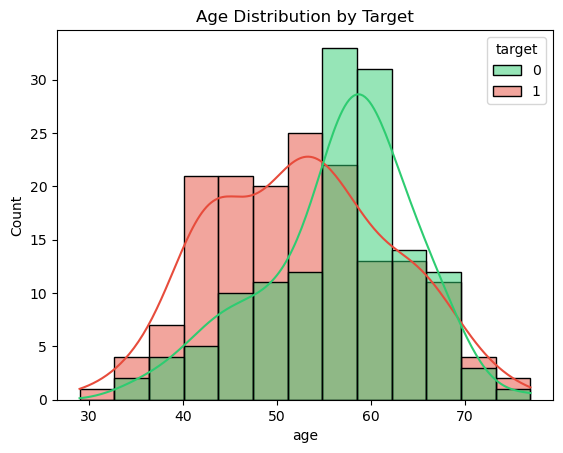

In [118]:
# Plot 1 - age
sns.histplot(data=df, x='age', hue='target', kde=True, palette=['#2ecc71', '#e74c3c'])
plt.title('Age Distribution by Target')
plt.show()

**Observation:** This Plot Shows a a local maximum at 45 and a global at 55 in the "1" showing a significant prescence of heart disease 

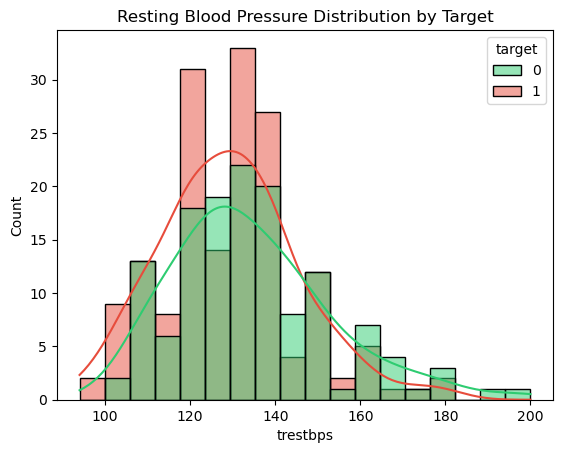

In [119]:
# Plot 2 - trestbps
sns.histplot(data=df, x='trestbps', hue='target', kde=True, palette=['#2ecc71', '#e74c3c'])
plt.title('Resting Blood Pressure Distribution by Target')
plt.show()

**Observation:** this plot shows that while both "0" & "1" fall in the range between 120-140 the patients with heart disease have a lower prescence by about an average count of 5 or so, so more of them fall in the ranges below the mean

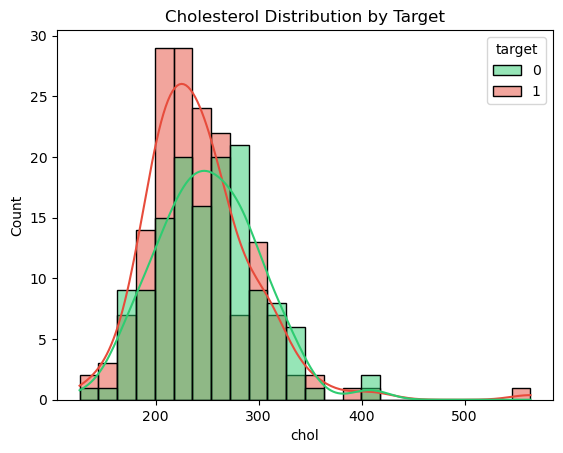

In [120]:
# Plot 3 - chol
sns.histplot(data=df, x='chol', hue='target', kde=True, palette=['#2ecc71', '#e74c3c'])
plt.title('Cholesterol Distribution by Target')
plt.show()

**Observation:** This plot shows that patients with heart disease are at risk of higher cholesterol levels

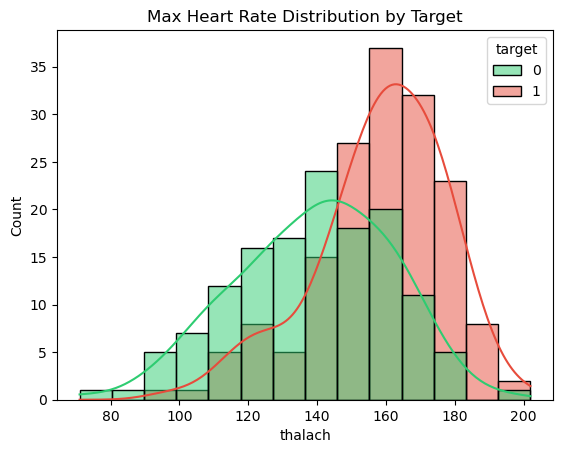

In [121]:
# Plot 4 - thalach
sns.histplot(data=df, x='thalach', hue='target', kde=True, palette=['#2ecc71', '#e74c3c'])
plt.title('Max Heart Rate Distribution by Target')
plt.show()

**Observation:** the Average Max Heart Rate for patients with Heart Disease is about 140 while healthy patients is 170 approximately of course so overall this shows that heart disease patients have a lower max heart rate than healthy ones by a significant gap at that

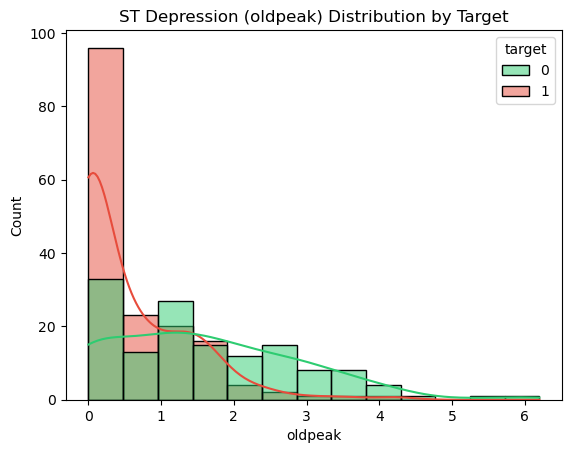

In [122]:
# Plot 5 - oldpeak
sns.histplot(data=df, x='oldpeak', hue='target', kde=True, palette=['#2ecc71', '#e74c3c'])
plt.title('ST Depression (oldpeak) Distribution by Target')
plt.show()

**Observation:** heart disease patients have significantly higher oldpeaks than healthy patients and high st depressions could inidicate an arterial blockage or reduced oxygen supply to the heart muscles

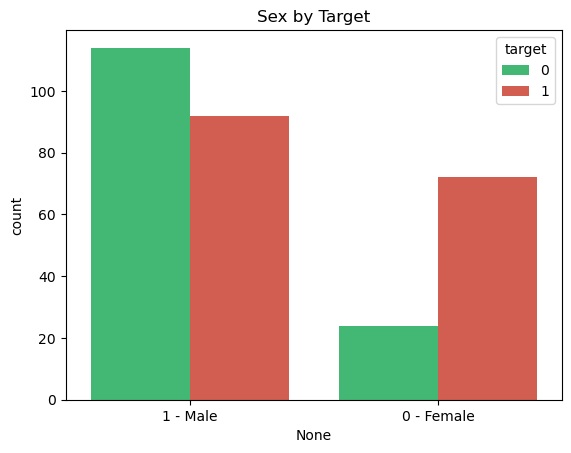

sex_label
Male      206
Female     96
Name: count, dtype: int64


In [123]:
# Plot 6 - sex
df['sex_label'] = df['sex'].map({1: 'Male', 0: 'Female'})
sex_x = df['sex'].astype('Int64').astype(str) + ' - ' + df['sex_label']
sns.countplot(data=df, x=sex_x, hue='target', palette=['#2ecc71', '#e74c3c'])
plt.title('Sex by Target')
plt.show()
print(df['sex_label'].value_counts())

**Observation:** the plot shows that the male to female ratio of HD is so skewed towards men having it but that's a bias by non-equal prescence and because female HD manifest with atypical symptoms so alot of the time it goes unnoticed and unreffered to trials which create such datasets so this plot is only useful as a male to male comparison due to the bias i might exclude it from predictions later 

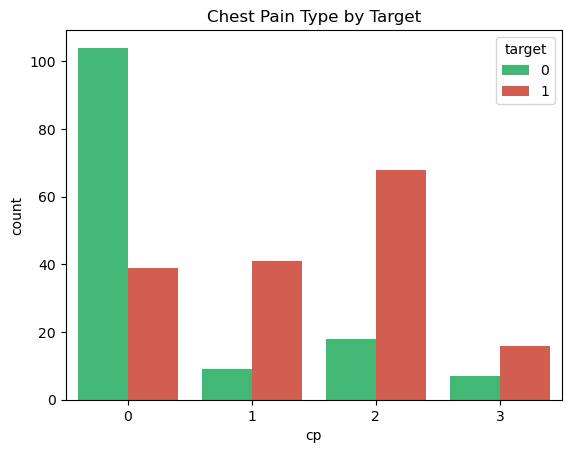

In [124]:
# Plot 7 - cp
sns.countplot(data=df, x='cp', hue='target', palette=['#2ecc71', '#e74c3c'])
plt.title('Chest Pain Type by Target')
plt.show()

**Observation:** this plot shows that heart disease patients while do not experience as high a cp as normal but their prescence spikes at the 3rd level vastly surpassing non-heart-disease patients in that level

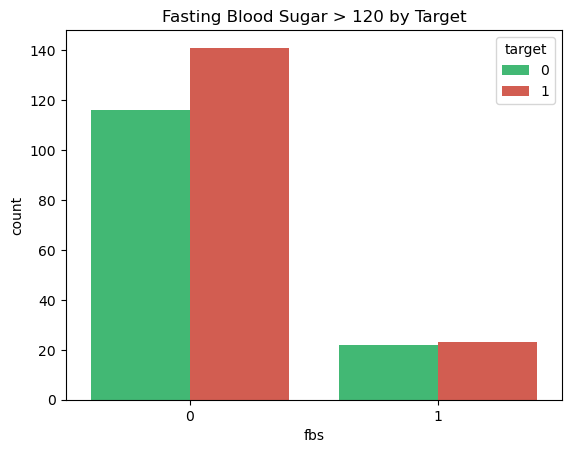

In [125]:
# Plot 8 - fbs
sns.countplot(data=df, x='fbs', hue='target', palette=['#2ecc71', '#e74c3c'])
plt.title('Fasting Blood Sugar > 120 by Target')
plt.show()

**Observation:** The plot shows a balance for diabetic/pre-diabetic patients in the HD and non-HD patients bec even tho diabetes is one of the biggest risk factors to HD the participants were chosen who already were experiencing cardiological effects so there is bias that shows as equal so it might be excluded as well cause this is not indicitave to real life medicine

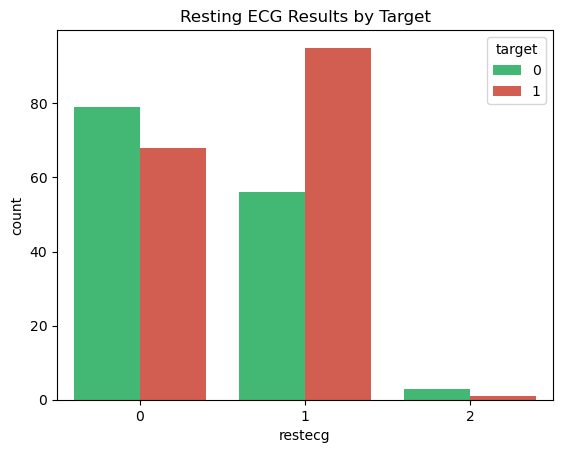

In [126]:
# Plot 9 - restecg
sns.countplot(data=df, x='restecg', hue='target', palette=['#2ecc71', '#e74c3c'])
plt.title('Resting ECG Results by Target')
plt.show()

**Observation:** this plot shows that at restecg == 0 non HD patients are  more prescent rather than at restecg == 1 where the HD patients have a more significant prescence and interestingly at restecg == 2 while both HD and Non-HD patients are extremely sparse but non-HD patients are more than double the HD ones

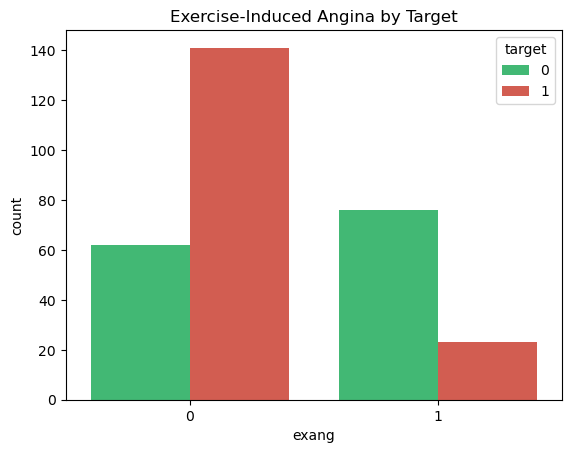

In [127]:
# Plot 10 - exang
sns.countplot(data=df, x='exang', hue='target', palette=['#2ecc71', '#e74c3c'])
plt.title('Exercise-Induced Angina by Target')
plt.show()

**Observation:** this plot shows that non-HD patients are more likely than HD patients to experience exang

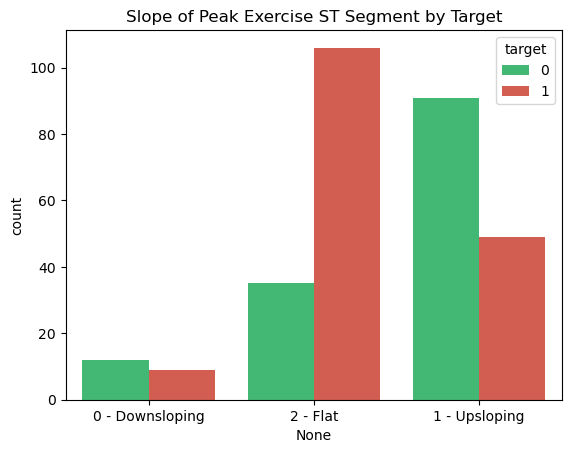

In [128]:
# Plot 11 - slope
df['slope_label'] = df['slope'].map({1: 'Upsloping', 2: 'Flat', 0: 'Downsloping'})
slope_x = df['slope'].astype('Int64').astype(str) + ' - ' + df['slope_label']
sns.countplot(x=slope_x, hue=df['target'], palette=['#2ecc71', '#e74c3c'])
plt.title('Slope of Peak Exercise ST Segment by Target')
plt.show()

**Observation:** this plot shows that at slope == 2 (Flat) HD patients have a significantly higher prescence than non-HD patients, while at slope == 1 (Upsloping) non-HD patients are much more prescent than HD patients. At slope == 0 (Downsloping), both groups have a relatively low prescence, but HD patients are slightly more prescent.

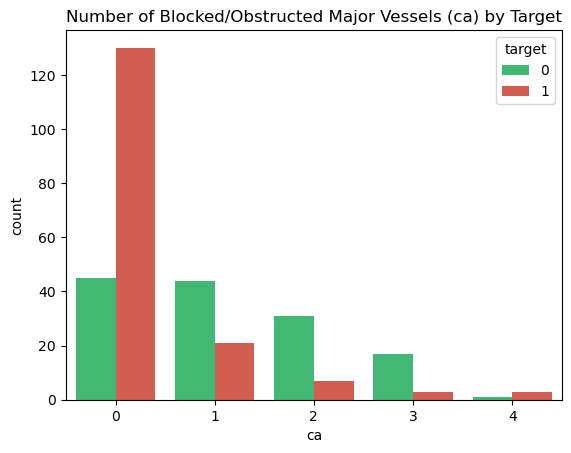

In [129]:
# Plot 12 - ca
sns.countplot(data=df, x='ca', hue='target', palette=['#2ecc71', '#e74c3c'])
plt.title('Number of Blocked/Obstructed Major Vessels (ca) by Target')
plt.show()

**Observation:** this plot describes how many major vessels are obstructed and we can see that ca == 0 (best case) non-HD patients are concentrated and HD patients have much more blocked or obstructed vessels with 1 the most common obstruction number to 3 being the least

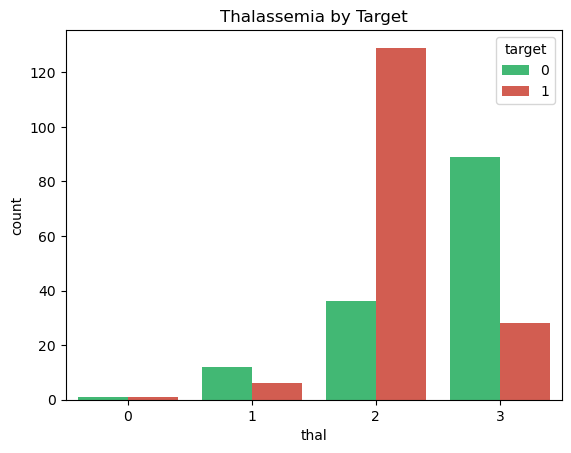

In [130]:
# Plot 13 - thal
sns.countplot(data=df, x='thal', hue='target', palette=['#2ecc71', '#e74c3c'])
plt.title('Thalassemia by Target')
plt.show()

* 0: Zero-Risk 
* Observation: healthy both groups are sparce here since this data is colleted from cardiovascular affected people in the first place
* 3: 
* Observation: Healthy (non-HD) patients are heavily concentrated in this category, which perfectly matches clinical expectations.
* 1: 
* Observation: Total patient counts are relatively low here. 
* 2: 
* Observation: Heart disease (HD) patients heavily concentrate in this category, so it is the strongest predictor of  dangerous cardiac distress.

### 1.3 Bivariate & Multivariate Analysis
Annotated correlation heatmap, pairplot for top-4 features, cross-tabulations for categorical features vs target. Note which features show the strongest separation.

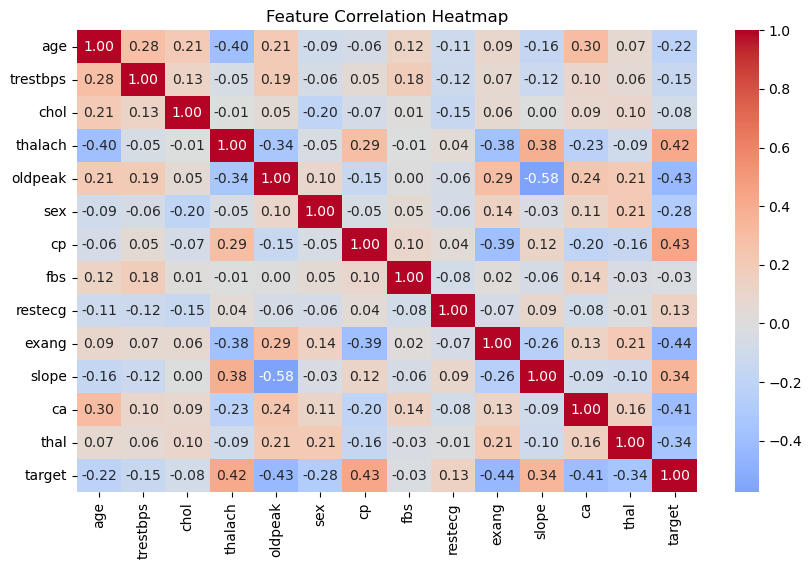

In [131]:
plt.figure(figsize=(10, 6))
corr = df[continuous_features + categorical_features + ['target']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

**Observation:** 
* The HeatMap shows that the the Target is most affected by 'exang','cp'and 'oldpeak','ca' in that specific order 
* The oldpeak and slope Relationship: A stronger correlation of 0.58 is observed between oldpeak and slope. This is entirely expected in real-world medicine

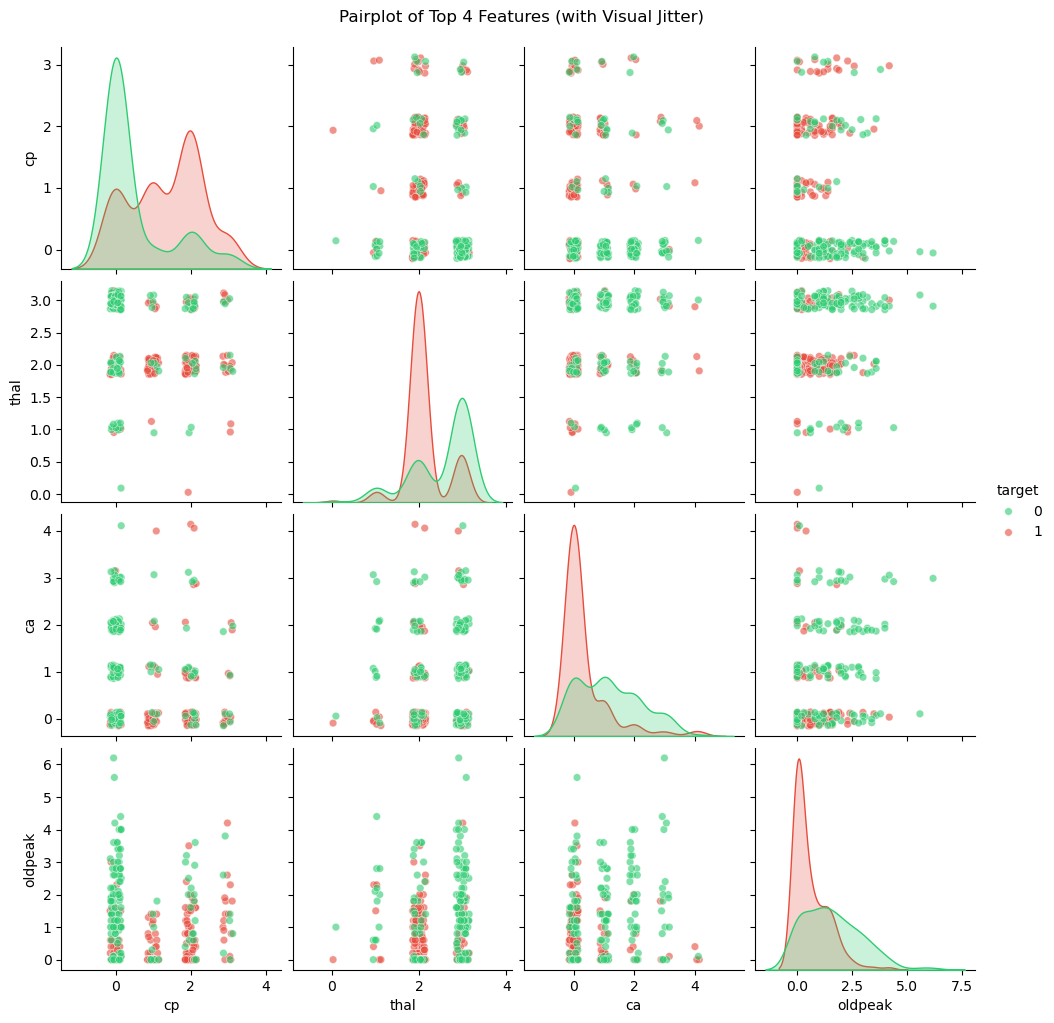

In [156]:
top4 = ['cp', 'thal', 'ca', 'oldpeak']
plot_df = df[top4 + ['target']].copy()

for col in ['cp', 'thal', 'ca']:
    plot_df[col] = plot_df[col] + np.random.uniform(-0.15, 0.15, size=len(plot_df))

sns.pairplot(plot_df, hue='target', palette=['#2ecc71', '#e74c3c'], plot_kws={'alpha': 0.6, 's': 30})
plt.suptitle("Pairplot of Top 4 Features (with Visual Jitter)", y=1.02)
plt.show()


**Observation:** this pairplot shows that oldpeak separates HD and non-HD patients the best, with non-HD patients mostly around 0 while HD patients spread towards higher values. It also shows that patients with ca == 0 and normal thal are mostly non-HD, while higher ca values and reversible defects are more common in HD patients. cp shows some separation too but the categories overlap more.

(i added jitter  because the plot had too much overlap it was basically unintelligble)

In [133]:
for feature in categorical_features:
    print(f"--- {feature} vs target ---")
    print(pd.crosstab(df[feature], df['target'], normalize='index') * 100)
    print()

--- sex vs target ---
target          0          1
sex                         
0       25.000000  75.000000
1       55.339806  44.660194

--- cp vs target ---
target          0          1
cp                          
0       72.727273  27.272727
1       18.000000  82.000000
2       20.930233  79.069767
3       30.434783  69.565217

--- fbs vs target ---
target          0          1
fbs                         
0       45.136187  54.863813
1       48.888889  51.111111

--- restecg vs target ---
target           0          1
restecg                      
0        53.741497  46.258503
1        37.086093  62.913907
2        75.000000  25.000000

--- exang vs target ---
target          0          1
exang                       
0       30.541872  69.458128
1       76.767677  23.232323

--- slope vs target ---
target          0          1
slope                       
0       57.142857  42.857143
1       65.000000  35.000000
2       24.822695  75.177305

--- ca vs target ---
target          0

### Bivariate Analysis: Cross-Tabulations vs. Target
**Observation:** the cross tab shows that ca, thal, exang and cp have the biggest differences between HD and non-HD patients. At ca == 0 only 26.1% of patients have HD, but at ca == 3 this increases to 85.0%. For thal, the normal scan is mostly non-HD at 77.7%, while the reversible defect group is mostly HD at 76.1%.

It also shows that patients with exang == 1 are mostly HD at 76.8%, while patients with exang == 0 are mostly non-HD at 69.1%. cp == 4 has the highest HD percentage at 72.9%, while cp == 2 is mostly non-HD at 82.0%.

The other features have less separation. slope == 1 is mostly non-HD at 74.6%, while slope == 2 and slope == 3 are more HD at 65.0% and 57.1%. Female patients are mostly non-HD at 74.2%, while male patients have 55.3% HD. restecg == 1 is mostly HD at 75.0%, but fbs is almost even with only a small difference between normal and high blood sugar, so it probably will not help much.

### 1.4 Feature Engineering (≥4 new features)
Create new features and justify each one — why does it make domain/clinical sense?

In [134]:
df['bp_chol_ratio'] = df['trestbps'] / df['chol']
df['age_hr_interaction'] = df['age'] * df['thalach']
df['hr_reserve'] = 220 - df['age'] - df['thalach']
df['vessel_defect_score'] = df['ca'] + df['thal']

* bp_chol_ratio: is useful to try 2 weakly correllated metrics to each other and the target to see if more value can be found in them and it flags people who are high on both risks
* age_hr_interaction: both are great measures with a strong corr between them as age is higher HD is more present and in the opposite but stronger the max heart rate when lower HD is more probable so medically this feauture asks is an old patient with low max heart rate at more risk of HD than a young but High Max Heart rate patient for example
* hr_reserve: an actual medical metric that see how much more reserve someone has and how far below max capacity they are the lower it is the more HD risk exist 
* vessel_defect_score: we use it to add two of the strongest +ve correlators of HD with each other into one severity score while also preserving the original 2 features to preserve variance

### 1.5 Outlier Detection & Handling
Box plots + IQR method. Document which features have outliers and your strategy (keep / cap / remove) with justification.

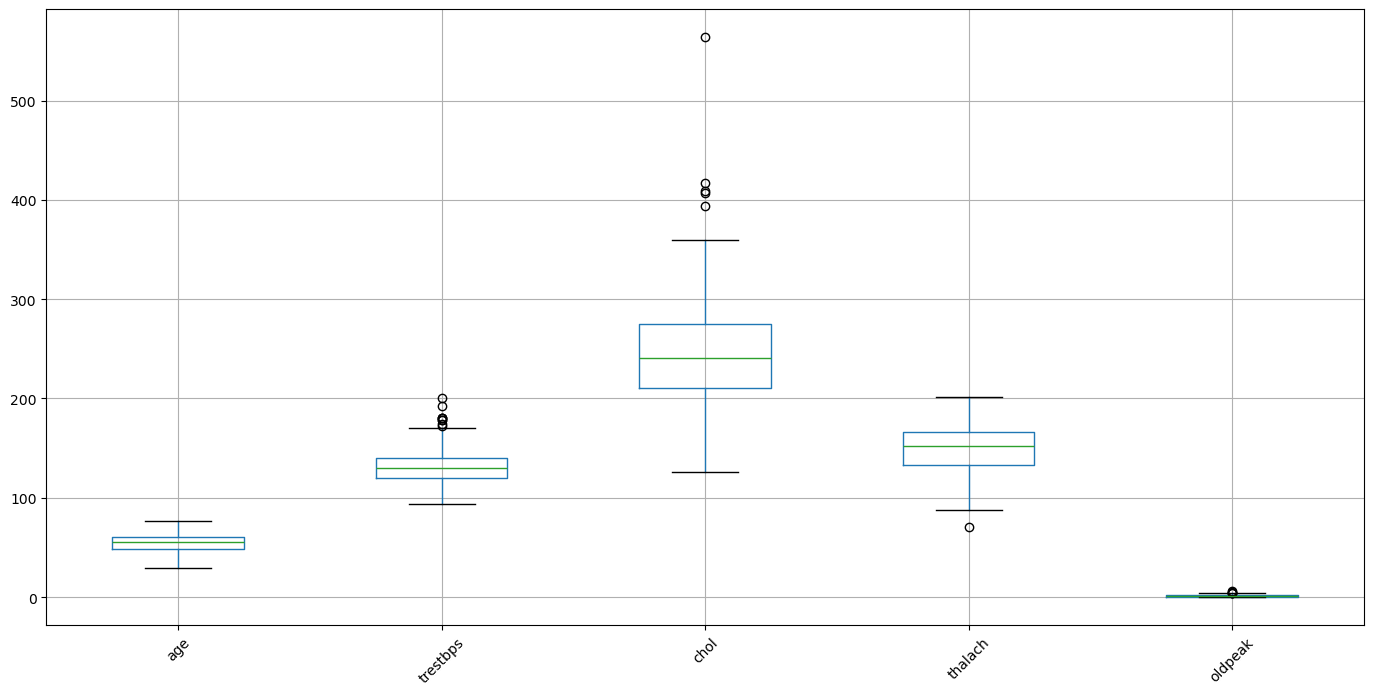

age: 0 outliers
trestbps: 9 outliers
chol: 5 outliers
thalach: 1 outliers
oldpeak: 5 outliers


In [135]:
plt.figure(figsize=(17, 8))
df[continuous_features].boxplot()
plt.xticks(rotation=45)
plt.show()

for col in continuous_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

### Descision:
* I decided to keep outlier since they are not not much in the first place and they could be genuine medical extremes and since we're going to use tree-based methods it's even more ok since they're quite resistant to outliers so need to make an already sparce dataset sparcer

---
## 2. Model Building & Training (25 points)

### 2.1 Train/Test Split
70/30 split, `stratify=y`, `random_state=42`.

In [136]:
feature_cols = [c for c in df.columns if c not in ['target', 'sex_label', 'slope_label']]
X = df[feature_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

### 2.2 Baseline Models (default parameters)
Train Decision Tree, Random Forest, Gradient Boosting, and XGBoost with default settings. Record baseline results.

In [137]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

baseline_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    baseline_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    }

pd.DataFrame(baseline_results).T

,Accuracy,Precision,Recall,F1,AUC-ROC
Decision Tree,0.758242,0.745455,0.836735,0.788462,0.751701
Random Forest,0.813187,0.775862,0.918367,0.841121,0.892857
Gradient Boosting,0.780220,0.754386,0.877551,0.811321,0.866375
XGBoost,0.758242,0.754717,0.816327,0.784314,0.868319


### 2.3 5-Fold Stratified Cross-Validation
Apply on the training set. Report Accuracy, Precision, Recall, F1, AUC-ROC as mean ± std across folds, for each model.

In [138]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {
        metric: f"{scores[f'test_{metric}'].mean():.3f} ± {scores[f'test_{metric}'].std():.3f}"
        for metric in scoring
    }

pd.DataFrame(cv_results).T

,accuracy,precision,recall,f1,roc_auc
Decision Tree,0.720 ± 0.056,0.736 ± 0.074,0.783 ± 0.082,0.753 ± 0.043,0.713 ± 0.061
Random Forest,0.820 ± 0.061,0.825 ± 0.089,0.878 ± 0.104,0.842 ± 0.048,0.903 ± 0.031
Gradient Boosting,0.810 ± 0.063,0.825 ± 0.120,0.870 ± 0.061,0.837 ± 0.036,0.890 ± 0.040
XGBoost,0.801 ± 0.066,0.810 ± 0.102,0.861 ± 0.093,0.826 ± 0.051,0.906 ± 0.034


### 2.4 Confusion Matrices & ROC Curves
Plot for each model on the test set.

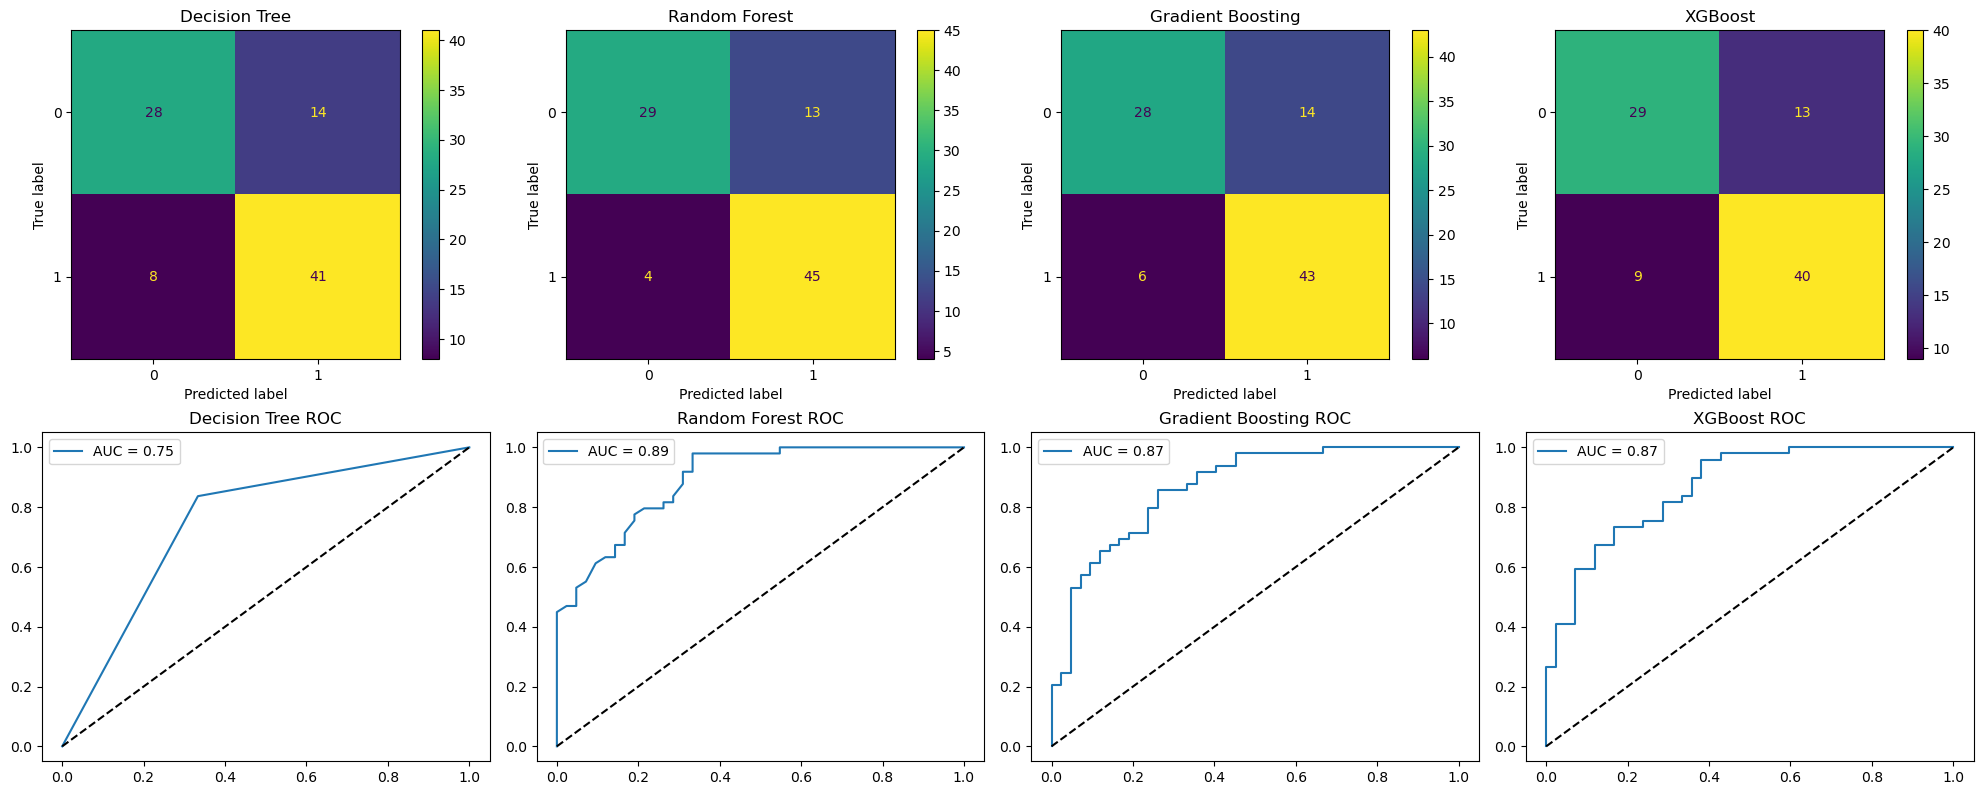

In [139]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(ax=axes[0, i])
    axes[0, i].set_title(f'{name}')

    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    axes[1, i].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.2f}')
    axes[1, i].plot([0, 1], [0, 1], 'k--')
    axes[1, i].set_title(f'{name} ROC')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

### 2.5 Results Comparison Table
Store all baseline results in a single DataFrame for side-by-side comparison.

In [140]:
comparison_df = pd.DataFrame(baseline_results).T
comparison_df

,Accuracy,Precision,Recall,F1,AUC-ROC
Decision Tree,0.758242,0.745455,0.836735,0.788462,0.751701
Random Forest,0.813187,0.775862,0.918367,0.841121,0.892857
Gradient Boosting,0.780220,0.754386,0.877551,0.811321,0.866375
XGBoost,0.758242,0.754717,0.816327,0.784314,0.868319


---
## 3. Hyperparameter Tuning (20 points)

### 3.1 Decision Tree Tuning
`RandomizedSearchCV`/`GridSearchCV`, 5-fold stratified CV. Tune: `max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion`, `max_features`.

In [141]:
dt_params = {
    'max_depth': [2, 4, 6, 8, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}
# 8 × 5 × 5 × 2 × 3 = 1,200 combos × 5 folds = 6,000 fits

dt_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
dt_search.fit(X_train, y_train)
print(dt_search.best_params_, dt_search.best_score_)

{'criterion': 'entropy', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 20} 0.8798970251716247


### 3.2 Random Forest Tuning
Tune: `n_estimators`, `max_depth`, `min_samples_split`, `max_features`, `bootstrap`.

In [142]:
rf_params = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}
# 5 × 6 × 3 × 2 × 2 = 360 combos × 5 folds = 1,800 fits 

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
rf_search.fit(X_train, y_train)
print(rf_search.best_params_, rf_search.best_score_)

{'bootstrap': True, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 150} 0.9216933638443937


### 3.3 Gradient Boosting Tuning
Tune: `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `min_samples_split`.

In [143]:
gb_params = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5, 6],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}
# 4 × 4 × 5 × 3 × 3 = 720 combos × 5 folds = 3,600 fits 

gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
gb_search.fit(X_train, y_train)
print(gb_search.best_params_, gb_search.best_score_)

{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_split': 5, 'n_estimators': 150, 'subsample': 0.8} 0.908649885583524


### 3.4 XGBoost Tuning
Tune: `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`.

In [144]:
xgb_params = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5, 6],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.5, 1],
    'reg_lambda': [0.5, 1, 2]
}
# 4 × 4 × 5 × 3 × 3 × 3 × 3 = 6,480 combos × 5 folds = 32,400 fits

xgb_search = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
xgb_search.fit(X_train, y_train)
print(xgb_search.best_params_, xgb_search.best_score_)

{'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 0.6} 0.927574370709382


### 3.5 Baseline vs Tuned Comparison Table

In [145]:
tuned_models = {
    'Decision Tree': dt_search.best_estimator_,
    'Random Forest': rf_search.best_estimator_,
    'Gradient Boosting': gb_search.best_estimator_,
    'XGBoost': xgb_search.best_estimator_
}

tuned_results = {}
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    tuned_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    }

baseline_df = pd.DataFrame(baseline_results).T.add_suffix('_baseline')
tuned_df = pd.DataFrame(tuned_results).T.add_suffix('_tuned')
pd.concat([baseline_df, tuned_df], axis=1)


,Accuracy_baseline,Precision_baseline,Recall_baseline,F1_baseline,AUC-ROC_baseline,Accuracy_tuned,Precision_tuned,Recall_tuned,F1_tuned,AUC-ROC_tuned
Decision Tree,0.758242,0.745455,0.836735,0.788462,0.751701,0.791209,0.750000,0.918367,0.825688,0.850340
Random Forest,0.813187,0.775862,0.918367,0.841121,0.892857,0.802198,0.754098,0.938776,0.836364,0.893100
Gradient Boosting,0.780220,0.754386,0.877551,0.811321,0.866375,0.813187,0.766667,0.938776,0.844037,0.870748
XGBoost,0.758242,0.754717,0.816327,0.784314,0.868319,0.802198,0.762712,0.918367,0.833333,0.892128


---
## 4. Deep Analysis & Visualization (25 points)

### 4.1 Feature Importance Comparison
Side-by-side bar plot (2×2 grid) for all 4 tuned models. Do all models agree on the most important features? Why or why not?

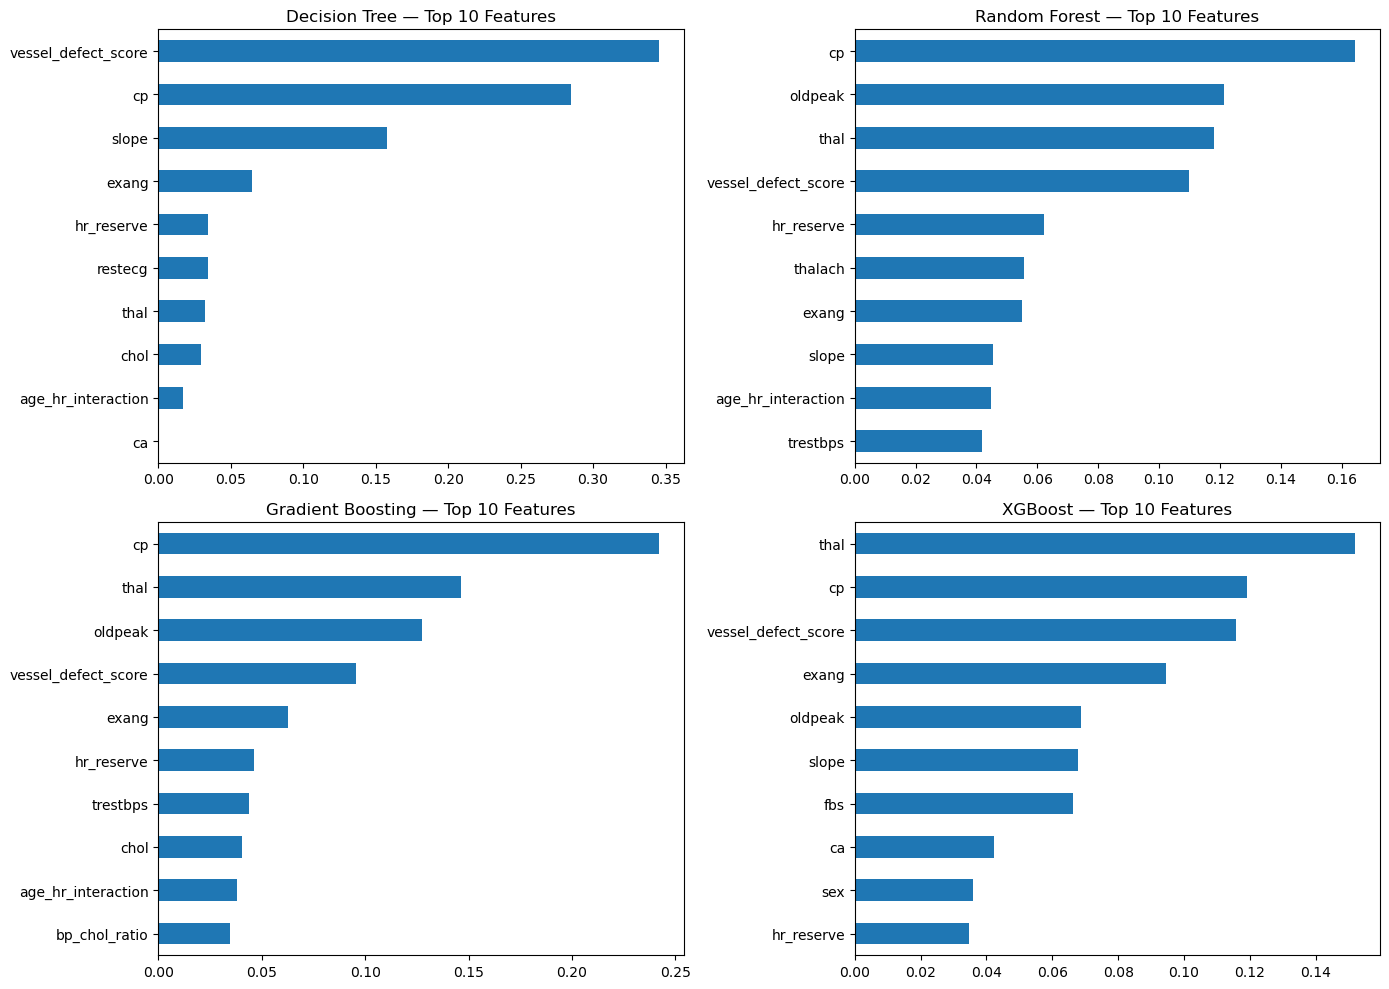

In [146]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(tuned_models.items()):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances.sort_values(ascending=True).tail(10).plot(kind='barh', ax=axes[i])
    axes[i].set_title(f'{name} — Top 10 Features')

plt.tight_layout()
plt.show()

*  cp is always first or second in the plots vessel defect once came first in the decision tree 4th in random and gradient 3rd in xgbwhile thal is consistently top 3 in all but thee desision tree where it's 7th in rand it's 3rd in grad 2nd in xgb it's 1st  so while they didn't always agree there was overlap because descision tree uses greedy method for example it settled on vessel_defect and never pivoted etc..

### 4.2 Decision Tree Visualization
`plot_tree` on the best Decision Tree, `max_depth=4` for readability. Interpret the first 2-3 splits in plain language.

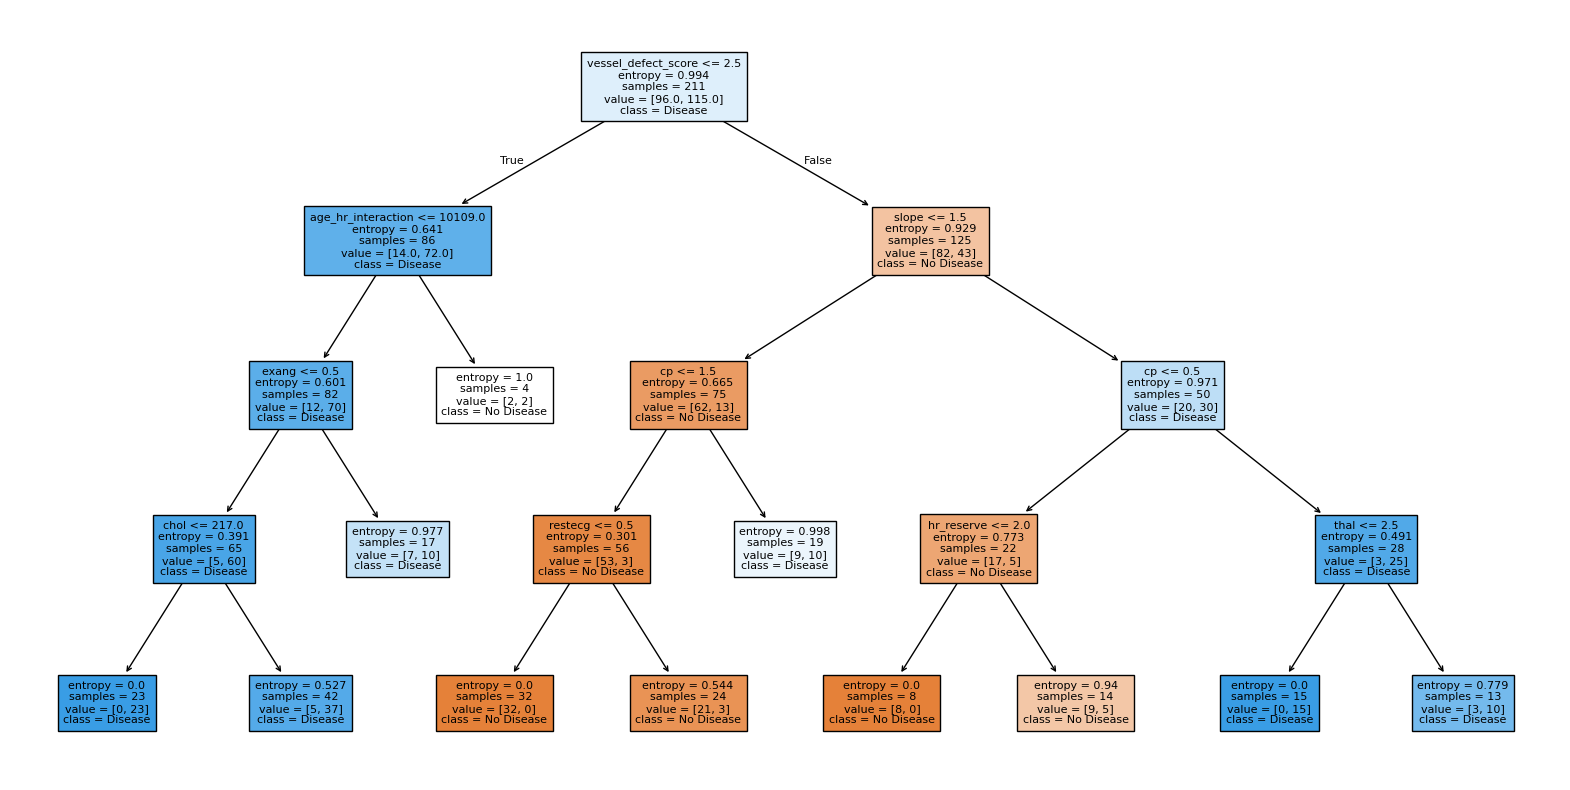

In [147]:
plt.figure(figsize=(20, 10))
plot_tree(dt_search.best_estimator_, max_depth=4, feature_names=X_train.columns,
          class_names=['No Disease', 'Disease'], filled=True, fontsize=8)
plt.show()

* i was unsure in creating vessel_defect_score if it would be meaningful and not just dilute the varicance but it ended up being the single best root of the tree and if it was true it pivoted to age_hr_interaction if false to slope and those to exang or no disease and cp respectively depending on thresholds and about 7 more splits later

### 4.3 XGBoost Learning Curves
Training vs validation log loss per boosting round. Identify if/where overfitting begins. Discuss early stopping.

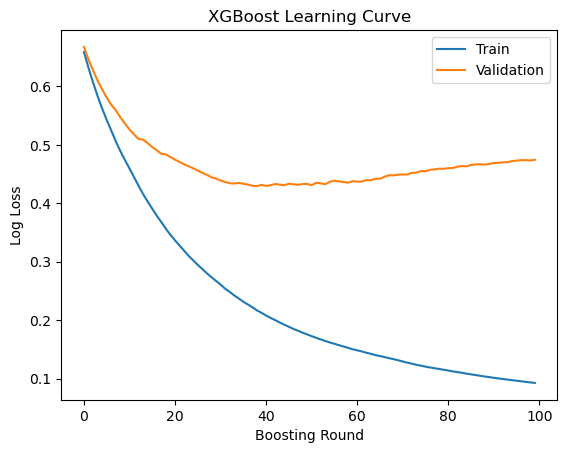

In [158]:
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

xgb_best_params = xgb_search.best_params_

xgb_lc_model = xgb.XGBClassifier(
    learning_rate=xgb_best_params['learning_rate'],
    random_state=42,
    eval_metric='logloss'
)


xgb_lc_model.fit(
    X_train_inner,
    y_train_inner,
    eval_set=[
        (X_train_inner, y_train_inner),
        (X_val, y_val)
    ],
    verbose=False
)
results = xgb_lc_model.evals_result()

plt.plot(results['validation_0']['logloss'], label='Train')
plt.plot(results['validation_1']['logloss'], label='Validation')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.legend()
plt.title('XGBoost Learning Curve')
plt.show()

* xgb curves the valid is on top trainis below and it's barely 0.1 log loss while valid ends on log loss about 0.45 the both intersect at the starting point which is about 4 or so bossting round i approximate ofc since it's in 20s per period and the moment of the split of the curves is the moment the overfitting starts so optimal boosting round are ~4-5 so early stopping should be before that point

### 4.4 Overfitting Analysis
Train vs test accuracy as a function of `max_depth` (1–20) for Decision Tree, and `n_estimators` for Random Forest. Mark the point where overfitting starts.

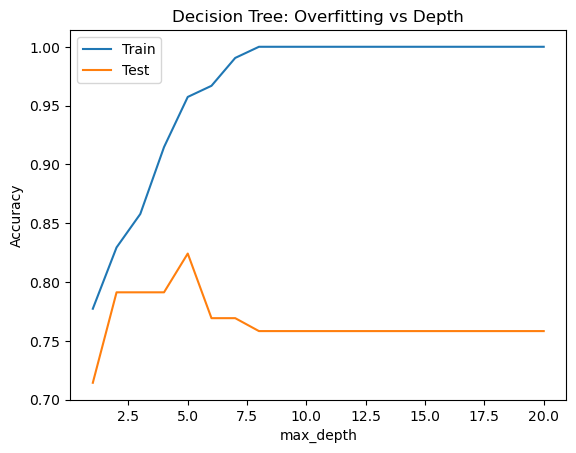

In [149]:
depths = range(1, 21)
train_scores, test_scores = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test, m.predict(X_test)))

plt.plot(depths, train_scores, label='Train')
plt.plot(depths, test_scores, label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Decision Tree: Overfitting vs Depth')
plt.show()

* Test accuracy peaks, around depth 3-5 ( 0.83) then drops to 0.75-0.76 by depth 8 while train continues to improve and reaches its limit. Depth 4-5 is the point where overfitting begins. After that more depth gives the tree memorization. This matches what the best parameters showed earlier.

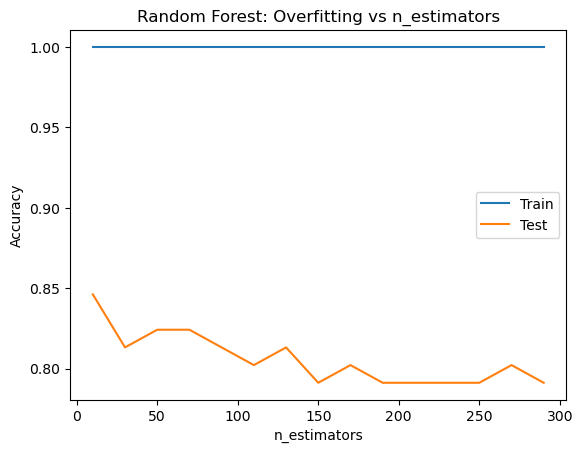

In [150]:
n_ests = range(10, 310, 20)
train_scores_rf, test_scores_rf = [], []

for n in n_ests:
    m = RandomForestClassifier(n_estimators=n, random_state=42)
    m.fit(X_train, y_train)
    train_scores_rf.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores_rf.append(accuracy_score(y_test, m.predict(X_test)))

plt.plot(n_ests, train_scores_rf, label='Train')
plt.plot(n_ests, test_scores_rf, label='Test')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Random Forest: Overfitting vs n_estimators')
plt.show()

* here overfitting starts as early as n_estimators and stays at the top but that doesn't mean much given that the RF model almost cancels out all noise 

### 4.5 Written Analysis 
a) Which model performed best and why? Connect it to theory (bias-variance tradeoff, data size, feature types).

b) Why might Decision Tree perform differently from Random Forest on this specific dataset?

c) Did boosting models improve over Random Forest? Is the improvement worth the added complexity?

d) Which hyperparameter had the biggest impact on XGBoost performance? Why?

e) In a real healthcare setting, which model would you deploy and why? Consider interpretability vs accuracy.

---
a) Random Forest model performed best for the needed field (not absolute best) it's metric were always best or second best at most baseline and tuned and it reduced variance enough without having to add many of the biases descision trees fall on due to the greedy path they take and variance reduction is more crucial in such small samples of records than bias reduction which boosted trees excel at but as the metric shows while the improvement exists it's not worth the drastically much higher processing time and power and for feature types we hade a mix of continous and categorical data which all models did equally as good at because tree are best when it comes to mixed data types so that had no consequences to think of 

b) descision tree performs worse than random forest here because past a depth 5 the accuracy of the test data fell sharply due to the tree memorizing the train data  causing overfitting while randome forests trees also do the same mistakes of memorization but they only look at a random part of the dataset then the average cancels most of the noise

c)no at baseline randome forest outdid every other model let alone boosting models and at tuning random forest was less than gradient boosting by 0.011 in accuracy but same as xgb's it lost to both by ~0.01 at prescision at recall it was higher tha xgb by 0.02 and equal to gradient boosting at recall it was barely higher than xgb and barely less than gradient boosted at AUC-ROC it beat both other scores so the improve over random forest barely existed most of the time or was reversed plus there were too much more complexity objectively random forest is the best model to this dataset  plus boosting models are harder to interpert 

d) the hyperparameter with most impact on xgb tuning was 'learning_rate" : 0.05 ,'colsample_bytree' : 0.6 it also picked optimum max depth at 4 which is concurrent with the plot of xgb learning curves 


e) i'd overwhelmingly vote for Random forest, Descision tree is most easily interprettable by an actual doctor but it's easy to overfit and not trustable enough for such a crucial field , hence why i think randome forest wins it is more complex but still readable and understandble and it also has best recall which is the most crucial metric for the field of medicine

---
## Bonus Challenges (+10 points each)

### Bonus 1 — SHAP Analysis
SHAP summary plot + force plot for individual predictions on XGBoost. Explain 2 specific predictions.

C:\Users\oufyw\AppData\Local\Temp\ipykernel_14256\848592523.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


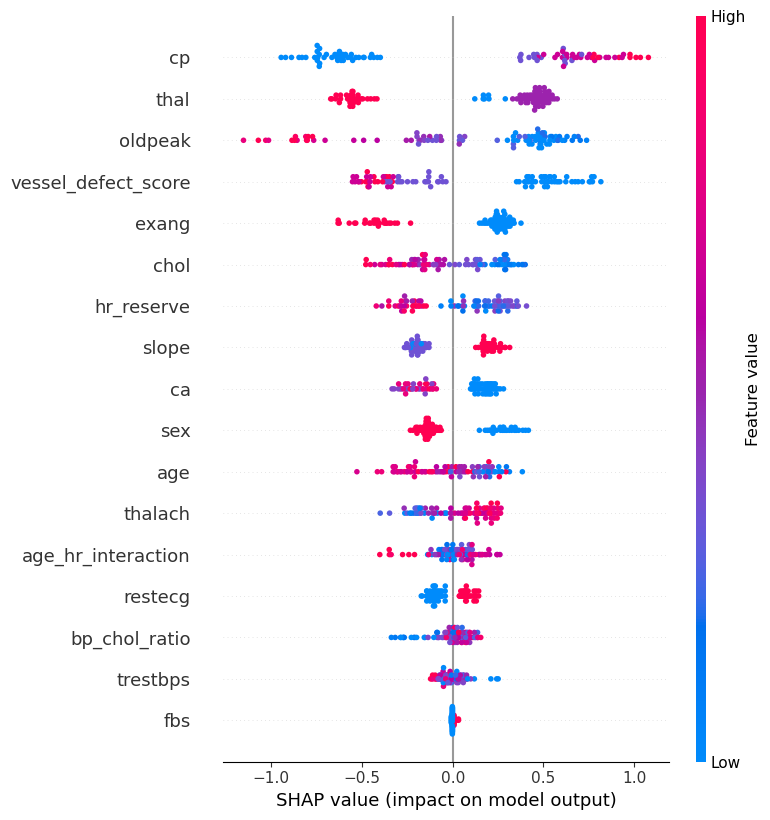

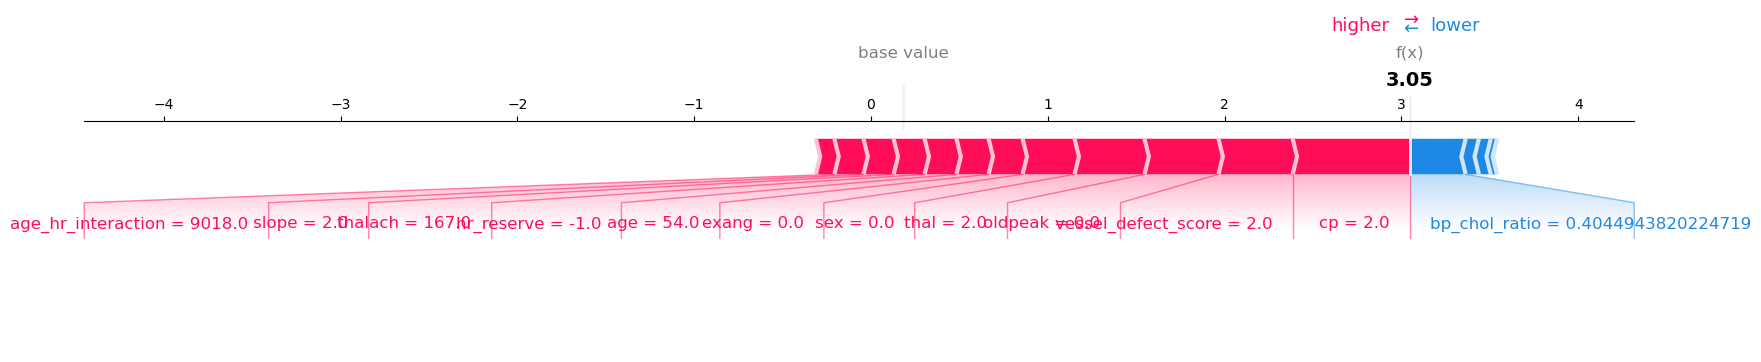

In [151]:

explainer = shap.TreeExplainer(xgb_search.best_estimator_)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

# force plot for two specific predictions — pick any two row indices from X_test
shap.initjs()
idx1, idx2 = 0, 1  # swap these for two you find interesting

shap.force_plot(explainer.expected_value, shap_values[idx1], X_test.iloc[idx1], matplotlib=True)


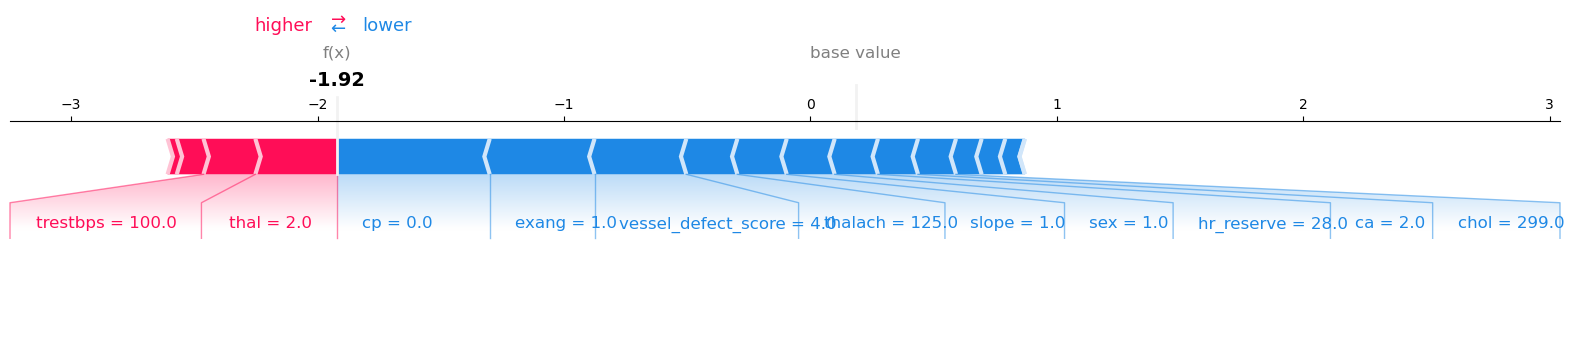

In [152]:
shap.force_plot(explainer.expected_value, shap_values[idx2], X_test.iloc[idx2], matplotlib=True)

* **Patient 1:** has HD shap shows us that what was the highest values that pushed the prediction is "cp", "Vessel", "oldpeak", and "thal" so like shown in the graphs it tracks also "age" == 54 is consistent with where HD concentrate 

* **Patient 2:** Is predicted to be a non-HD patient what affected that was his low "cp", "exang" which is congruent with our interpretations of the plots  

### Bonus 2 — Cost-Sensitive Learning
Use `class_weight` / `scale_pos_weight` to optimize for recall (false negatives are costlier in healthcare). Compare with standard results.

In [153]:
xgb_cost_sensitive = xgb.XGBClassifier(
    **{k: v for k, v in xgb_search.best_params_.items()},
    scale_pos_weight=3,  # try 1, 1.5, 2, 3 and compare — weights positive (disease) class higher
    random_state=42,
    eval_metric='logloss'
)
xgb_cost_sensitive.fit(X_train, y_train)
y_pred_cs = xgb_cost_sensitive.predict(X_test)

cost_sensitive_results = {
    'Accuracy': accuracy_score(y_test, y_pred_cs),
    'Precision': precision_score(y_test, y_pred_cs),
    'Recall': recall_score(y_test, y_pred_cs),
    'F1': f1_score(y_test, y_pred_cs),
    'AUC-ROC': roc_auc_score(y_test, xgb_cost_sensitive.predict_proba(X_test)[:, 1])
}

pd.DataFrame([tuned_results['XGBoost'], cost_sensitive_results], index=['Standard XGBoost', 'Cost-Sensitive XGBoost'])

,Accuracy,Precision,Recall,F1,AUC-ROC
Standard XGBoost,0.802198,0.762712,0.918367,0.833333,0.892128
Cost-Sensitive XGBoost,0.813187,0.750000,0.979592,0.849558,0.885326


**Observation:** after the cost-sensetive optimization we can see  an increase in accuracy , F1 and most important of them the Recall with a huge increase of 0.06 that matters most hence why the small drop in AUC-ROC and precision is worth it, this was achieved through scale_pos_weight = 3 while other values were tried this was the best weight balance that sacrificed the least while exploding the recall improvement and making the other metric still somewhat dependable

### Bonus 3 — Stacking Ensemble
Stacking classifier with all 4 models as base estimators, Logistic Regression as meta-learner. Does it beat XGBoost alone?

In [154]:

base_estimators = [
    ('dt', dt_search.best_estimator_),
    ('rf', rf_search.best_estimator_),
    ('gb', gb_search.best_estimator_),
    ('xgb', xgb_search.best_estimator_)
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

stacking_results = {
    'Accuracy': accuracy_score(y_test, y_pred_stack),
    'Precision': precision_score(y_test, y_pred_stack),
    'Recall': recall_score(y_test, y_pred_stack),
    'F1': f1_score(y_test, y_pred_stack),
    'AUC-ROC': roc_auc_score(y_test, stacking_model.predict_proba(X_test)[:, 1])
}

pd.DataFrame([tuned_results['XGBoost'], stacking_results], index=['XGBoost', 'Stacking Ensemble'])

,Accuracy,Precision,Recall,F1,AUC-ROC
XGBoost,0.802198,0.762712,0.918367,0.833333,0.892128
Stacking Ensemble,0.813187,0.775862,0.918367,0.841121,0.896987


**Observation:** we can see that the stacking_model shows improvement to all metric except recall where no change occurs tho the improvement is not vast it's still worth the extra accuracy of all metrics

### Bonus 4 — Pipeline + Deployment
`sklearn.Pipeline` with preprocessing + best model. Save with `joblib`. Write a `predict_patient()` function.

In [155]:


final_pipeline = Pipeline([
    ('Random Forest', rf_search.best_estimator_) 
])
final_pipeline.fit(X_train, y_train)

joblib.dump(final_pipeline, 'heart_disease_pipeline.pkl')

def predict_patient(patient_dict):
    patient_df = pd.DataFrame([patient_dict])[X_train.columns]
    pred = final_pipeline.predict(patient_df)[0]
    prob = final_pipeline.predict_proba(patient_df)[0][1]
    return ('Disease' if pred == 1 else 'No Disease', round(prob, 3))

# example usage 
sample_patient = X_test.iloc[0].to_dict()
predict_patient(sample_patient)

('Disease', np.float64(0.919))